In [1]:
from arcgis import GIS
from arcgis.raster import ImageryLayer
from arcgis.raster.functions import apply, clip, ndvi, ndwi, mask, stretch, colormap
from arcgis.geometry import Polygon
from arcgis.geometry.filters import intersects, within
import datetime as dt
from ipywidgets import HBox, Layout

C:\Users\odin0\AppData\Local\ESRI\conda\envs\arcgispro-py3-clone\Lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
gis = GIS()

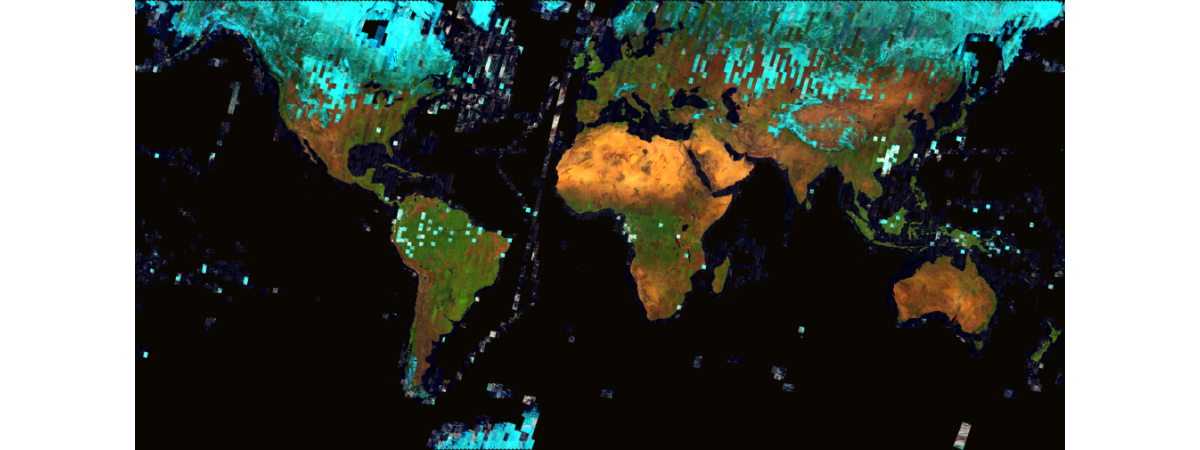

In [3]:
landsat_imagery = ImageryLayer("https://landsat2.arcgis.com/arcgis/rest/services/Landsat/MS/ImageServer")

landsat_imagery

In [4]:
rotterdam_aoi = Polygon({
    "rings": [
        [
            [4.0500, 51.9600],   # Hoek van Holland - noordwest
            [4.0500, 51.8500],   # Hoek van Holland - zuidwest
            [4.6000, 51.8500],   # Kralingen Oost - zuidoost
            [4.6000, 51.9600],   # Kralingen Oost - noordoost
            [4.0500, 51.9600]    # sluit polygon
        ]
    ],
    "spatialReference": {"wkid": 4326}
})


In [5]:
# Create a variable called map that is an instance of the gis.map class.
map1 = gis.map()

# Draw the fayoum_aoi polygon object on the map.
map1.content.draw(shape=rotterdam_aoi)

# Set the extent of the map to the envelope of the feature.
map1.extent = dict(rotterdam_aoi.envelope)

# Draw the map.
map1

Map(extent={'xmin': 4.05, 'ymin': 51.85, 'xmax': 4.6, 'ymax': 51.96, 'spatialReference': SpatialReference({'wk…

In [6]:
# --- First try: scenes fully within the AOI ---
selected_within = landsat_imagery.filter_by(
    time=[dt.datetime(2022, 2, 1), dt.datetime(2022, 3, 31)],
    geometry=within(rotterdam_aoi)
)

# Query for the single least-cloudy scene
result_within = selected_within.query(
    out_fields="AcquisitionDate, GroupName, CloudCover, DayOfYear",
    order_by_fields="CloudCover",
    result_record_count=1
)

# --- Check if result has records ---
if len(result_within.features) > 0:
    print("Fully within aoi")
    # Use the 'within' result
    query_result = result_within
else:
    print("Intersect aoi")
    # --- Fallback: scenes that intersect the AOI ---
    selected_intersects = landsat_imagery.filter_by(
        time=[dt.datetime(2022, 2, 1), dt.datetime(2022, 3, 31)],
        geometry=intersects(rotterdam_aoi)
    )

    # Get top 5 least-cloudy intersecting scenes
    query_result = selected_intersects.query(
        out_fields="AcquisitionDate, GroupName, CloudCover, DayOfYear",
        order_by_fields="CloudCover",
        result_record_count=5
    )

# Convert to dataframe (works for either case)
df = query_result.sdf

# Display the result
df

Fully within aoi


,OBJECTID,AcquisitionDate,GroupName,CloudCover,DayOfYear,SHAPE
0,3502900,2022-02-27 10:33:53,LC08_L1TP_198024_20220227_20220309_02_T1_MTL,0.0022,24,"{""rings"": [[[750022.9233999997, 6852262.111000..."


In [7]:
# Make a variable containing the first scene, referenced by OBJECTID. Get the first scene.
# Python lists can be accessed by index number, and index values start at 0, so [0] is the first item.
selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[0]['OBJECTID']}")

# Get the other scenes down the list (not currently used, will be used later).
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[1]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[2]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[3]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[4]['OBJECTID']}")

# Make a map.
map2 = gis.map()

# Add the layer to the map.
map2.content.add(selected_scene)
                                           
# Add the AOI polygon to the map.                                       
map2.content.draw(shape=rotterdam_aoi)

# Set the extent of the map to the envelope of the AOI.
map2.extent = dict(rotterdam_aoi.envelope)
                                           
# Draw the map.
map2

Map(extent={'xmin': 4.05, 'ymin': 51.85, 'xmax': 4.6, 'ymax': 51.96, 'spatialReference': SpatialReference({'wk…

In [8]:
# Create a variable, fayoum_clipped, to hold the result of clipping the selected scene using the AOI polygon.
rotterdam_clipped = clip(selected_scene,
                  geometry=rotterdam_aoi)

In [9]:
# Create a variable to hold the NDVI raster derived from the image. 
# The raster will highlight vegetation.
rotterdam_ndvi = ndvi(rotterdam_clipped,
                    band_indexes="5 4")

# Create a variable to hold the NDWI raster derived from the image.
# The raster will highlight water. 
rotterdam_ndwi = ndwi(rotterdam_clipped,
                    band_indexes="5 3")

In [10]:
# Define the side_by_side function to display two maps together in the Jupyter notebook results.
def side_by_side(raster_1, raster_2, map_extent):
    """ Method for displaying 2 rasters side by side (on the same map extent) """
    # Create the maps.
    map_1 = gis.map()
    map_2 = gis.map()
    
    # Add the input rasters to the maps.
    map_1.content.add(raster_1)
    map_2.content.add(raster_2)
    
    # Set the extents to be the same using the specified input extent.
    map_1.extent = map_2.extent = map_extent
    
    # Synchronize navigation of the maps.
    map_1.sync_navigation(map_2)

    # Define a layout for each map.
    map_1.layout=Layout(flex='1 1', padding='6px',  width='50%')
    map_2.layout=Layout(flex='1 1', padding='6px',  width='50%')
    
    # Make a horizontal box layout widget to show the two maps.
    box = HBox([map_1, map_2])
    
    # Return the widget to show the maps.
    return box

In [11]:
# Call the side_by_side function and set its parameters to the two spectral index rasters 
# and the extent.
side_by_side(raster_1=rotterdam_ndvi,
          raster_2=rotterdam_ndwi,
          map_extent=dict(rotterdam_aoi.envelope))

NDVI Band Histogram

Wat de waarden betekenen:
-1 tot 0: Water, wolken, of soms sneeuw en rotsen.
0 tot 0,1: Gebieden zonder vegetatie, zoals asfalt, stenen, gebouwen en kale grond.
0,2 tot 0,4: Lage positieve waarden, typisch voor grasland en struikgewas.
Hoger dan 0,4: Hoge positieve waarden, die wijzen op dichte vegetatie zoals bos, regenwoud of hoogproductieve akkerbouw.



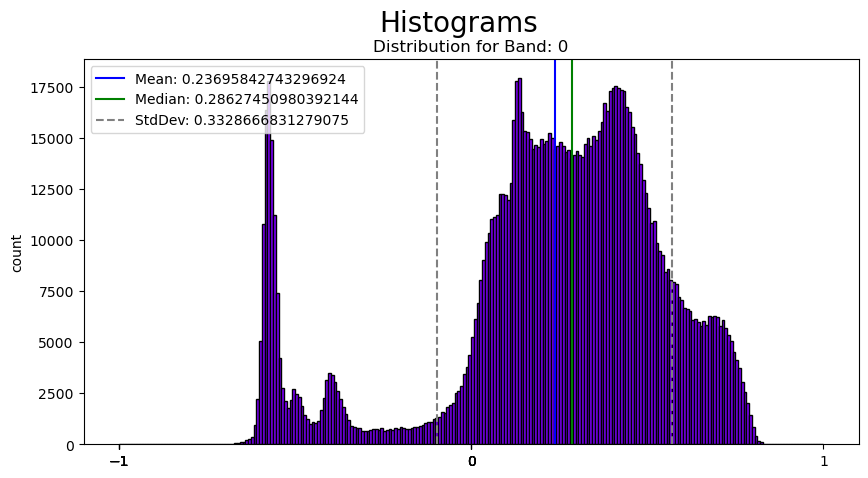

In [12]:
# Print a title.
print("""NDVI Band Histogram
""")

print("""Wat de waarden betekenen:
-1 tot 0: Water, wolken, of soms sneeuw en rotsen.
0 tot 0,1: Gebieden zonder vegetatie, zoals asfalt, stenen, gebouwen en kale grond.
0,2 tot 0,4: Lage positieve waarden, typisch voor grasland en struikgewas.
Hoger dan 0,4: Hoge positieve waarden, die wijzen op dichte vegetatie zoals bos, regenwoud of hoogproductieve akkerbouw.
""")


# Plot the histogram for the NDVI image.
rotterdam_ndvi.plot_histograms(geometry=rotterdam_aoi,
                             plot_properties={"figsize":(10,5)})

NDWI Band Histogram

Wat de waarden betekenen

    Positieve waarden (> 0): Geven aan dat er water aanwezig is.
        Hoge positieve waarden (> 0,5): Wijzen vaak op grote waterlichamen zoals meren en rivieren.
        Lage positieve waarden: Kunnen duiden op vochtige vegetatie of vochtige bodem.
    Negatieve waarden (< 0): Duiding op afwezigheid van water, zoals droge grond of niet-wateroppervlakken.
    


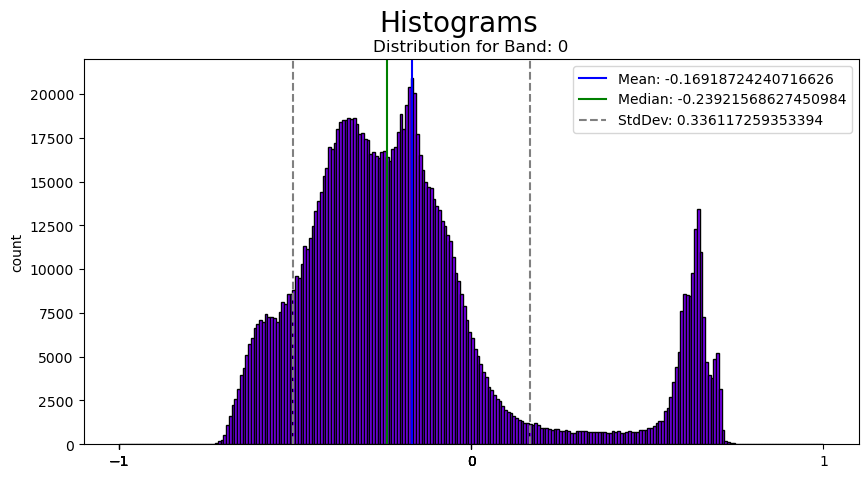

In [13]:
# Print a title.
print("""NDWI Band Histogram
""")

print("""Wat de waarden betekenen

    Positieve waarden (> 0): Geven aan dat er water aanwezig is.
        Hoge positieve waarden (> 0,5): Wijzen vaak op grote waterlichamen zoals meren en rivieren.
        Lage positieve waarden: Kunnen duiden op vochtige vegetatie of vochtige bodem.
    Negatieve waarden (< 0): Duiding op afwezigheid van water, zoals droge grond of niet-wateroppervlakken.
    """)

# Plot the histogram for the NDWI image.
rotterdam_ndwi.plot_histograms(geometry=rotterdam_aoi,
                             plot_properties={"figsize":(10,5)})